<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Modeling: Simple Linear Regression

### নোটবুক পরিচিতি (Metadata)

* **Aim:** গাড়ির গতিবেগ (Speed) এবং থামার দূরত্বের (Stopping Distance) মধ্যকার সম্পর্ক বিশ্লেষণ করা এবং ভবিষ্যৎ ফলাফল প্রেডিক্ট করা।
* **Dataset:** R-এর ক্লাসিক `cars` ডেটাসেট।
* **Key Skills:** Linear Regression (`lm`), Model Summary, Residual Analysis, এবং Prediction।

---

## লিনিয়ার রিগ্রেশন কেন শিখবেন?

- ১. **সম্পর্ক নির্ণয়:** একটি ভ্যারিয়েবল (যেমন: স্পিড) বাড়লে অন্যটি (যেমন: ডিসট্যান্স) কীভাবে পরিবর্তিত হয় তা গাণিতিকভাবে বোঝা যায়।
- ২. **ভবিষ্যদ্বাণী (Prediction):** বর্তমান ডেটা ব্যবহার করে অজানা পরিস্থিতির ফলাফল অনুমান করা।
- ৩. **মডেল ফিটিং:** ডেটার মধ্যে লুকানো প্যাটার্ন খুঁজে বের করে একটি সরলরেখার মাধ্যমে তা প্রকাশ করা।

---


## ১. এনভায়রনমেন্ট সেটআপ ও ডেটা পরিচিতি (Setup)

প্রথমে প্রয়োজনীয় লাইব্রেরি লোড করি এবং আমাদের ডেটাসেটটি এক পলক দেখে নিই।


In [ ]:
# library
library(tidyverse)


In [ ]:
# Quick look at the data
head(cars)

,speed,dist
,<dbl>,<dbl>
1,4,2
2,4,10
3,7,4
4,7,22
5,8,16
6,9,10


## ২. ভিজ্যুয়ালাইজেশন: স্পিড বনাম ডিসট্যান্স (The Plot)

মডেল তৈরির আগে ডেটার ট্রেন্ড দেখা জরুরি। আমরা `geom_smooth(method = lm)` ব্যবহার করে রিগ্রেশন লাইনটি দেখব।


`geom_smooth()` using formula = 'y ~ x'


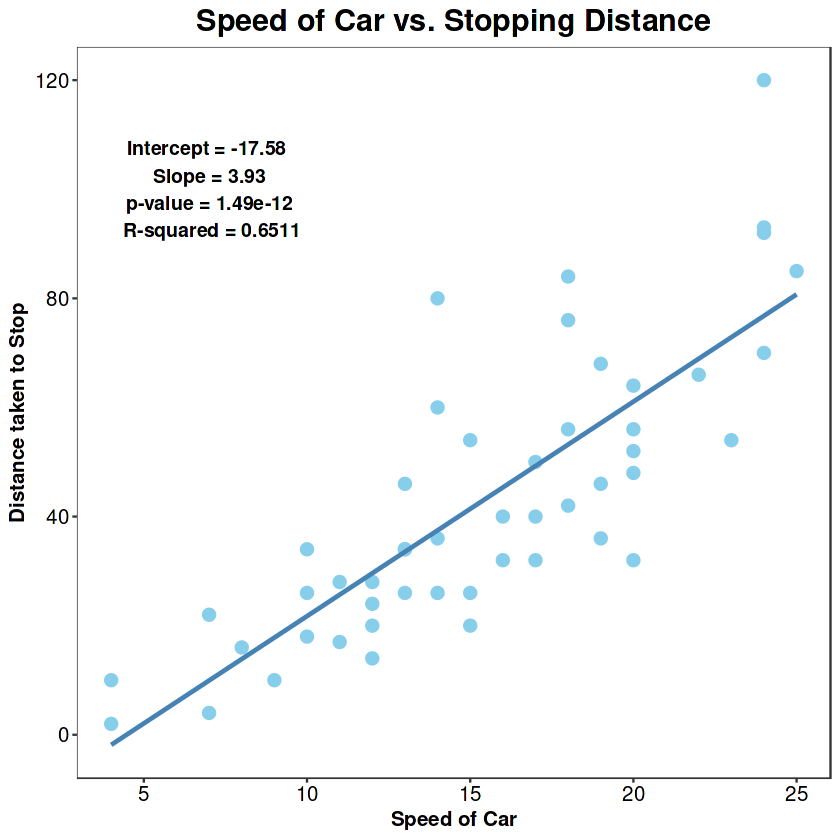

In [ ]:
cars %>%
  ggplot(aes(speed, dist)) +
  geom_point(size = 3, color = "skyblue") +
  geom_smooth(method = lm, se = F, color = "steelblue") +
  theme_test() +
  labs(title = "Speed of Car vs. Stopping Distance",
       x = "Speed of Car",
       y = "Distance taken to Stop") +
  theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
        axis.text = element_text(size = 12, color = "black"),
        axis.title = element_text(size = 12, face = "bold")) +
  # ইন্টারসেপ্ট এবং অন্যান্য রেজাল্ট অ্যানোটেট করা
  annotate("text", x = 7, y = 100,
           label = "Intercept = -17.58 \n Slope = 3.93 \n p-value = 1.49e-12 \n R-squared = 0.6511",
           color = "black", fontface = "bold", size = 4)

## ৩. লিনিয়ার মডেল তৈরি (Building the Model)

এখন আমরা গাণিতিক মডেলটি তৈরি করব এবং এর সামারি থেকে গুরুত্বপূর্ণ মানগুলো বের করব।


In [ ]:
# Building the linear model
linear_model <- lm(dist ~ speed, data = cars)
summary(linear_model)



Call:
lm(formula = dist ~ speed, data = cars)

Residuals:
    Min      1Q  Median      3Q     Max 
-29.069  -9.525  -2.272   9.215  43.201 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -17.5791     6.7584  -2.601   0.0123 *  
speed         3.9324     0.4155   9.464 1.49e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 15.38 on 48 degrees of freedom
Multiple R-squared:  0.6511,	Adjusted R-squared:  0.6438 
F-statistic: 89.57 on 1 and 48 DF,  p-value: 1.49e-12


**ব্যাখ্যা:**

* **R-squared (0.6511):** এর মানে হলো স্পিড দিয়ে আমরা ডিসট্যান্সের প্রায় ৬৫% পরিবর্তন ব্যাখ্যা করতে পারি।
* **p-value:** এটি অত্যন্ত ছোট ($1.49 \times 10^{-12}$), যা প্রমাণ করে যে স্পিড এবং ডিসট্যান্সের সম্পর্কটি কাকতালীয় নয়।

---

## ৪. মডেলের নির্ভুলতা পরীক্ষা (Residual Analysis)

মডেলটি কতটা সঠিক তা বোঝার জন্য রেসিড্যুয়াল (আসল মান ও প্রেডিক্টেড মানের পার্থক্য) পরীক্ষা করা হয়।


In [ ]:
# View residuals
attributes(linear_model)


$names
 [1] "coefficients"  "residuals"     "effects"       "rank"         
 [5] "fitted.values" "assign"        "qr"            "df.residual"  
 [9] "xlevels"       "call"          "terms"         "model"        

$class
[1] "lm"

In [ ]:
linear_model$residuals

1          2          3          4          5          6          7 
  3.849460  11.849460  -5.947766  12.052234   2.119825  -7.812584  -3.744993 
         8          9         10         11         12         13         14 
  4.255007  12.255007  -8.677401   2.322599 -15.609810  -9.609810  -5.609810 
        15         16         17         18         19         20         21 
 -1.609810  -7.542219   0.457781   0.457781  12.457781 -11.474628  -1.474628 
        22         23         24         25         26         27         28 
 22.525372  42.525372 -21.407036 -15.407036  12.592964 -13.339445  -5.339445 
        29         30         31         32         33         34         35 
-17.271854  -9.271854   0.728146 -11.204263   2.795737  22.795737  30.795737 
        36         37         38         39         40         41         42 
-21.136672 -11.136672  10.863328 -29.069080 -13.069080  -9.069080  -5.069080 
        43         44         45         46         47         48         49 
  2.930920  -2.933898 -18.866307  -6.798715  15.201285  16.201285  43.201285 
        50 
  4.268876

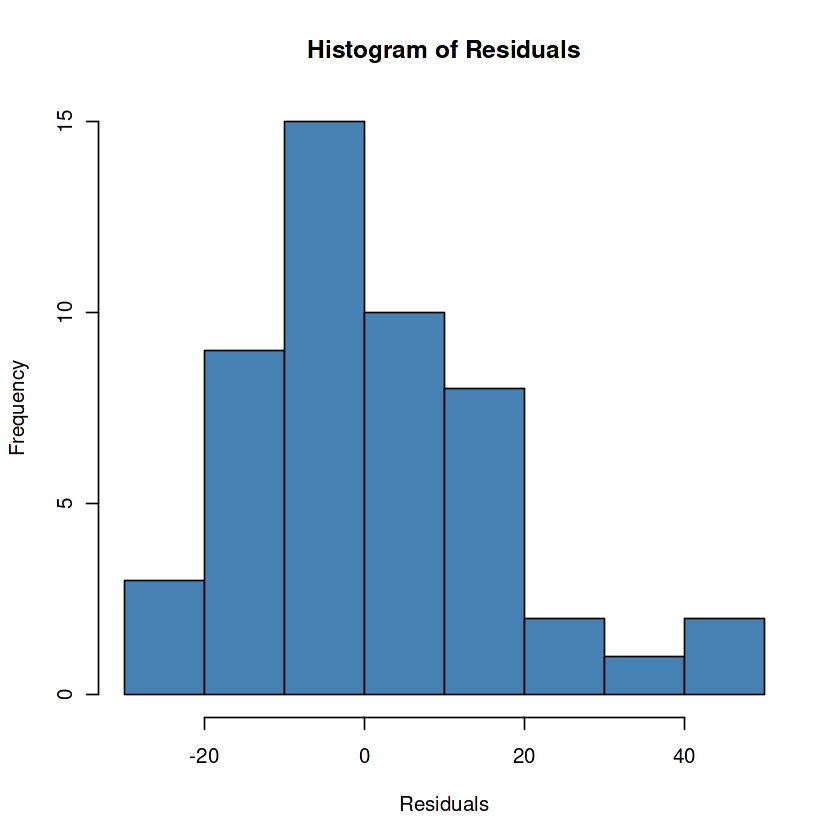

In [ ]:
# রেসিড্যুয়ালের ডিস্ট্রিবিউশন দেখা
hist(linear_model$residuals,
     main = "Histogram of Residuals",
     xlab = "Residuals",
     col = "steelblue")

**নোট:** যদি হিস্টোগ্রামটি মোটামুটি **Normal Distribution** (ঘণ্টার মতো আকৃতি) দেখায়, তবে বুঝতে হবে মডেলটি ভালো হয়েছে।

## ৫. প্রেডিকশন বা ভবিষ্যৎ অনুমান (Making Predictions)

মডেল তো তৈরি হলো, এবার নতুন কিছু স্পিড (১০, ১৫, ২০) দিলে গাড়ি থামতে কত দূরত্ব নেবে তা প্রেডিক্ট করি।


In [ ]:
# নতুন স্পিড ডেটা তৈরি
new_speed <- data.frame(speed = c(10, 15, 20))

# প্রেডিকশন জেনারেট করা
predict(linear_model, new_speed) %>%
  round(1)

1    2    3 
21.7 41.4 61.1

### **প্রো-টিপ (এক লাইনে প্রেডিকশন):**

In [ ]:
cars %>%
  lm(dist ~ speed, data = .) %>%
  predict(data.frame(speed = c(10, 15, 20))) %>%
  round()

1  2  3 
22 41 61

---

## এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):

* **`lm(y ~ x)`**: লিনিয়ার মডেল তৈরির প্রধান কমান্ড।
* **`summary()`**: ইন্টারসেপ্ট, স্লোপ এবং $R^2$ দেখার জন্য।
* **`residuals()`**: মডেলের ত্রুটি বা পার্থক্য চেক করার জন্য।
* **`predict()`**: নতুন ডেটার ওপর ভিত্তি করে ফলাফল অনুমান করা।

---